# Nail Anemia Classification  Data Preparation Module (Notebook 4)

Prepares a 3-class severity dataset (Normal, Leve/Mild, Moderado/Moderate)
from fingernail photographs  the fourth nail-category dataset, feeding
into the multi-site anemia fusion model.

**Dataset source (research paper):** [Non-invasive multimodal dataset for
the detection of iron deficiency anemia in young adults — RCSI, 2025](https://revistas.unsm.edu.pe/index.php/rcsi/article/view/955)
(Valles-Coral et al., DOI: 10.51252/rcsi.v5i2.955, CC BY 4.0)

**Note:** data obtained directly from the authors.

## What this notebook does

1. **Load images + metadata**  909 patients total in `metadata.csv`
   (age, sex, symptoms, Hb level, heart rate, etc.), but only 823 have
   a linked nail photo (`UNAS` column). Images are pre-sorted into
   `Normal` / `Leve` / `Moderada` folders by severity.

2. **Join folder images with metadata** by patient ID  823 of 826
   folder images matched; 3 unmatched extras (duplicate second photos
   with no metadata row) were dropped.

3. **Kept 3-class labels as-is** (Normal / Leve / Moderado) rather than
   collapsing to binary Anemic/Non_Anemic  per team decision, to allow
   experimenting with dropping or merging the ambiguous "Moderado"
   class at training time.

4. **Important structural difference from Notebook 3 (Figshare dataset):**
   each photo shows 3 fingers for framing/stability, but **only the
   middle finger's nail is the labeled target**  there are no
   per-finger bounding boxes in the metadata (unlike Notebook 3's
   Figshare dataset, which had 3 labeled nail boxes per patient).
   So this notebook extracts **1 crop per patient** (823 total), not 3.

5. **Fixed-fraction crop**  no bounding boxes were provided, so a
   crop region was manually calibrated by visually testing fraction
   values against sample photos (top=0.32, bottom=0.62, left=0.30,
   right=0.70 of image dimensions), since the camera framing was
   consistent across all 2992x2992 photos. Resized to 224x224.

6. **Artifact check**  0% across all 3 classes. The dark background
   is a genuine studio backdrop (not an export artifact), confirmed
   visually and via even distribution across classes.

**Final output:** `df` dataframe (823 images) with `final_path` column
at `/kaggle/working/peru_nail_final/`, saved as
`/kaggle/working/peru_nail_final_clean.csv`.

In [1]:
#Step_0: Dataset config + path verify
DATASET_META = {
    "dataset_name": "Non-Invasive Multimodal Anemia Dataset (Peru/UNSM)",
    "dataset_url": "https://revistas.unsm.edu.pe/index.php/rcsi/article/view/955",
    "kaggle_slug": "shahrozkhalid11/peru-nail-anemia-v4",
    "kaggle_input_path": "/kaggle/input/datasets/shahrozkhalid11/peru-nail-anemia-v4",
    "surface": "Nail",
    "target_classes": ["Normal", "Leve", "Moderada", "Severa"]
}

from pathlib import Path
DATASET_ROOT = Path(DATASET_META["kaggle_input_path"])

if not DATASET_ROOT.exists():
    DATASET_ROOT = Path(f"/kaggle/input/{DATASET_META['kaggle_slug'].split('/')[-1]}")

# handle extra nesting level (zip created a subfolder with the same name)
if not (DATASET_ROOT / "unas").exists():
    nested = DATASET_ROOT / DATASET_ROOT.name
    if (nested / "unas").exists():
        DATASET_ROOT = nested

assert (DATASET_ROOT / "unas").exists(), f"'unas' folder not found under: {DATASET_ROOT}"

print(f"Verified: {DATASET_META['dataset_name']}")
print(f"Mounted Path: {DATASET_ROOT}")

Verified: Non-Invasive Multimodal Anemia Dataset (Peru/UNSM)
Mounted Path: /kaggle/input/datasets/shahrozkhalid11/peru-nail-anemia-v4/peru-nail-anemia-v4


In [2]:
#Step_1: See Metadata
unas_dir = DATASET_ROOT / "unas"
print("Nail image counts by severity:")
for cls_dir in sorted(unas_dir.iterdir()):
    if cls_dir.is_dir():
        n_files = len([f for f in cls_dir.iterdir() if f.is_file()])
        print(f"  {cls_dir.name}: {n_files} images")

total_images = sum(len([f for f in cls_dir.iterdir() if f.is_file()])
                    for cls_dir in unas_dir.iterdir() if cls_dir.is_dir())
print(f"\nTotal nail images: {total_images}")

meta_path = DATASET_ROOT / "metadata.csv"
print(f"\nmetadata.csv exists: {meta_path.exists()}")
if meta_path.exists():
    import pandas as pd
    meta = pd.read_csv(meta_path)
    print(f"Metadata rows: {len(meta)}")
    print(f"Columns: {list(meta.columns)}")
    print(meta.head())

Nail image counts by severity:
  Leve: 202 images
  Moderada: 73 images
  Normal: 551 images

Total nail images: 826

metadata.csv exists: True
Metadata rows: 909
Columns: ['ID', 'Sexo', 'Edad', 'Fatiga', 'Debilidad', 'Latidos irregulares', 'Dificultad para respirar', 'Mareos o aturdimiento', 'Dolor en el pecho', 'Manos y pies fríos', 'Dolores de cabeza', 'Normal', 'Leve', 'Moderado', 'Frecuencia Cardiaca', 'Hemoglobina', 'Oxígeno', 'Peso', 'Talla', 'YEMAS', 'PALMAS', 'UNAS']
      ID Sexo Edad  Fatiga  Debilidad  Latidos irregulares  \
0  ID001    M   25       0          0                    1   
1  ID002    M   25       1          1                    0   
2  ID003    M   23       0          0                    0   
3  ID004    F   23       1          1                    0   
4  ID005    F   24       0          0                    0   

   Dificultad para respirar  Mareos o aturdimiento  Dolor en el pecho  \
0                         0                      0                  0   


In [3]:
#Step 2 : Build Image Table (Folder Listing)
print(f"Total metadata rows: {len(meta)}")
print(f"Rows with non-null UNAS (nail photo) filename: {meta['UNAS'].notna().sum()}")
print(f"Rows with null UNAS: {meta['UNAS'].isna().sum()}")

# severity breakdown from metadata itself (one-hot columns: Normal, Leve, Moderado)
print("\nSeverity counts (from metadata one-hot columns):")
print(f"  Normal: {meta['Normal'].sum()}")
print(f"  Leve: {meta['Leve'].sum()}")
print(f"  Moderado: {meta['Moderado'].sum()}")

# cross-check: severity counts only among rows that HAVE a nail photo
has_nail = meta[meta['UNAS'].notna()]
print(f"\nSeverity counts (only patients WITH nail photo, n={len(has_nail)}):")
print(f"  Normal: {has_nail['Normal'].sum()}")
print(f"  Leve: {has_nail['Leve'].sum()}")
print(f"  Moderado: {has_nail['Moderado'].sum()}")

Total metadata rows: 909
Rows with non-null UNAS (nail photo) filename: 823
Rows with null UNAS: 86

Severity counts (from metadata one-hot columns):
  Normal: 623
  Leve: 211
  Moderado: 75

Severity counts (only patients WITH nail photo, n=823):
  Normal: 556
  Leve: 196
  Moderado: 71


In [4]:
#Step 3 — Join Images with Metadata by Patient ID
records = []
for cls_dir in sorted(unas_dir.iterdir()):
    if not cls_dir.is_dir():
        continue
    for f in cls_dir.iterdir():
        if f.is_file() and f.suffix.lower() == ".jpg":
            patient_id = f.stem  # e.g. "ID004"
            records.append({"patient_id": patient_id, "path": str(f),
                             "filename": f.name, "folder_severity": cls_dir.name})

img_df = pd.DataFrame(records)
print(f"Images found in folders: {len(img_df)}")

# join with metadata on patient_id / ID
merged = img_df.merge(meta, left_on="patient_id", right_on="ID", how="left", indicator=True)

print(f"\nMerge result:")
print(merged["_merge"].value_counts())

unmatched = merged[merged["_merge"] == "left_only"]
print(f"\nImages with NO matching metadata row: {len(unmatched)}")
if len(unmatched) > 0:
    print(unmatched[["patient_id", "folder_severity"]].head(10))

df = merged[merged["_merge"] == "both"].drop(columns=["_merge"]).reset_index(drop=True)
print(f"\nFinal joined dataset: {len(df)} images")
print(df["folder_severity"].value_counts())

Images found in folders: 826

Merge result:
_merge
both          823
left_only       3
right_only      0
Name: count, dtype: int64

Images with NO matching metadata row: 3
    patient_id folder_severity
85     ID651_2            Leve
138    ID451_2            Leve
771    ID370_2          Normal

Final joined dataset: 823 images
folder_severity
Normal      550
Leve        200
Moderada     73
Name: count, dtype: int64


In [5]:
#Step 4 — Assign Final Class Labels (Normal / Leve / Moderado)
df["class_name"] = df["folder_severity"].replace({"Moderada": "Moderado"})
print(df["class_name"].value_counts())

class_name
Normal      550
Leve        200
Moderado     73
Name: count, dtype: int64


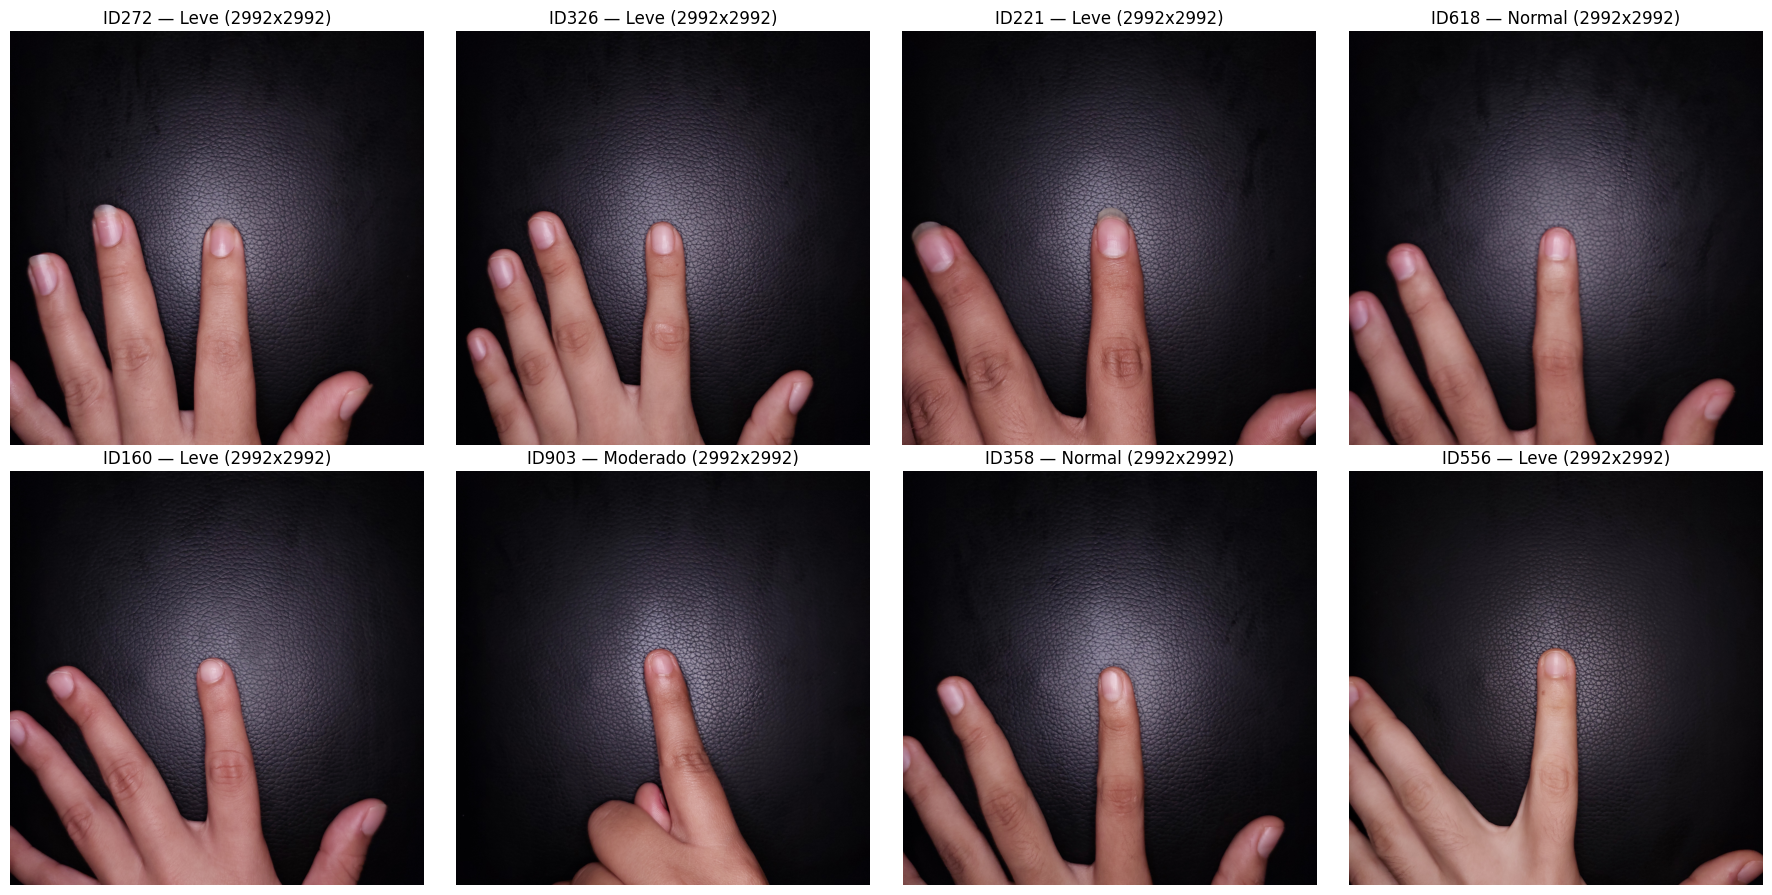

In [6]:
#Step 5 — Visual Check: Original Raw Images
import matplotlib.pyplot as plt
import cv2

sample = df.sample(8, random_state=2)
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, (_, row) in zip(axes.flat, sample.iterrows()):
    img = cv2.imread(row["path"])
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{row['patient_id']} — {row['class_name']} ({img.shape[1]}x{img.shape[0]})")
    ax.axis("off")
plt.tight_layout()
plt.show()

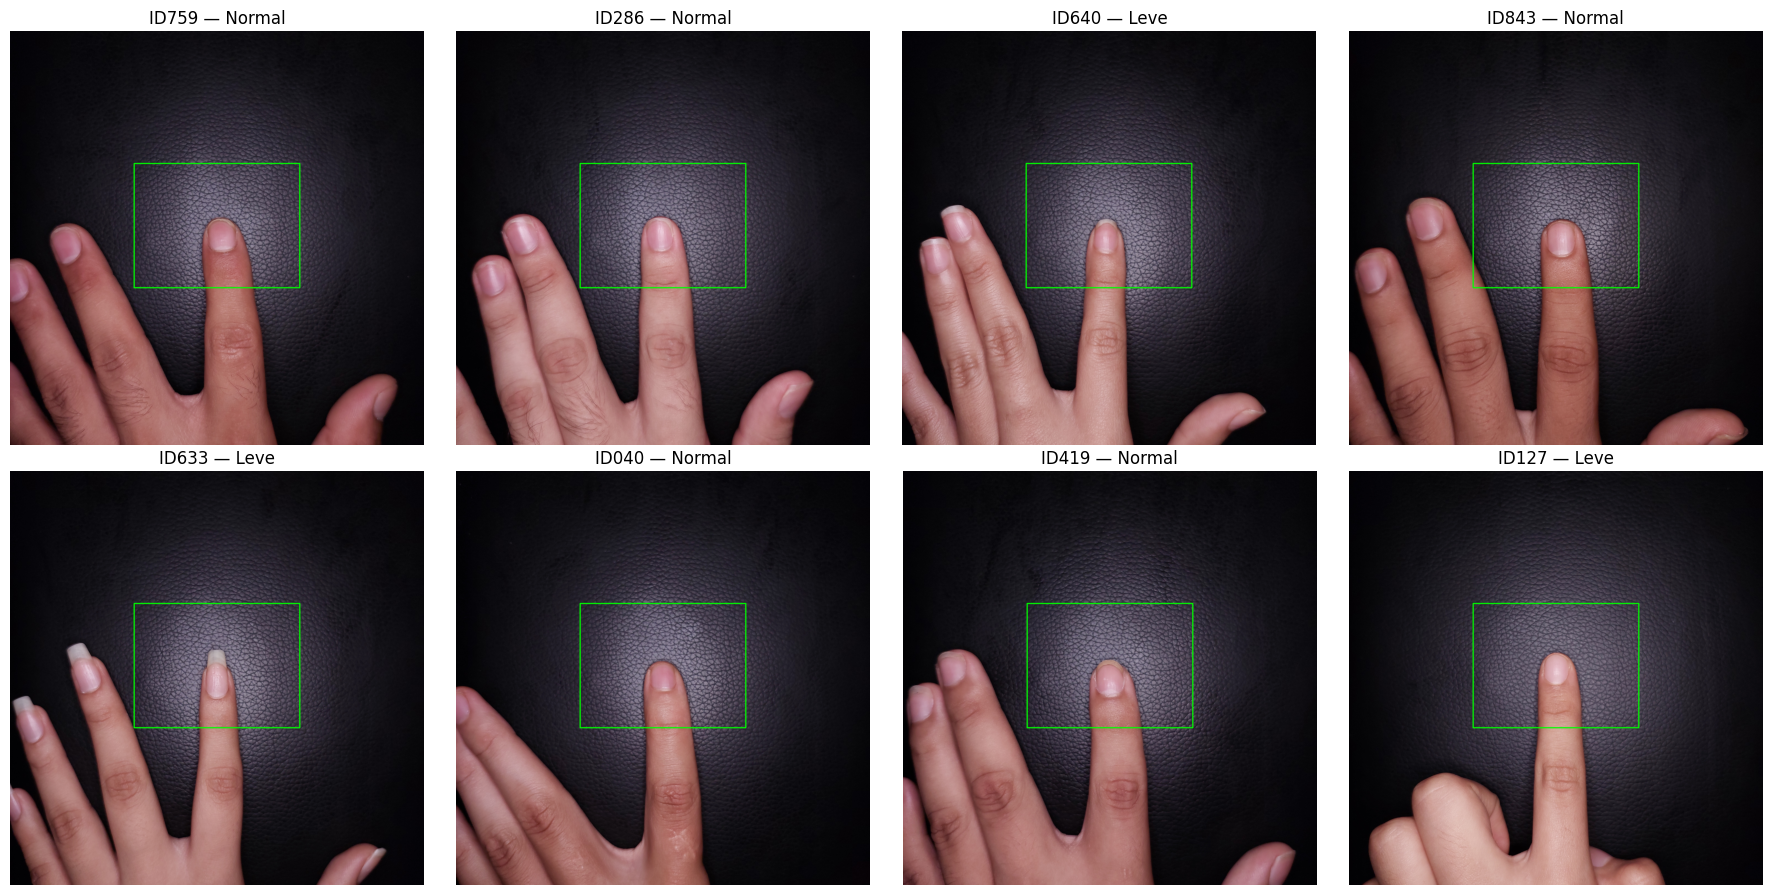

In [7]:
#Step 6 — Calibrate Fixed-Crop Region (Iterative Bounding-Box Preview)

sample = df.sample(8, random_state=3)
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

top_frac, bottom_frac, left_frac, right_frac = 0.32, 0.62, 0.30, 0.70

for ax, (_, row) in zip(axes.flat, sample.iterrows()):
    img = cv2.imread(row["path"])
    h, w = img.shape[:2]
    top, bottom = int(h * top_frac), int(h * bottom_frac)
    left, right = int(w * left_frac), int(w * right_frac)

    vis = img.copy()
    cv2.rectangle(vis, (left, top), (right, bottom), (0, 255, 0), 8)
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{row['patient_id']} — {row['class_name']}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [8]:
#Step 7 — Apply Fixed Crop + Resize to Full Dataset

from pathlib import Path

OUTPUT_DIR = Path("/kaggle/working/peru_nail_final")
IMG_SIZE = (224, 224)
TOP_FRAC, BOTTOM_FRAC, LEFT_FRAC, RIGHT_FRAC = 0.32, 0.62, 0.30, 0.70

def fixed_nail_crop(img, top_frac=TOP_FRAC, bottom_frac=BOTTOM_FRAC, left_frac=LEFT_FRAC, right_frac=RIGHT_FRAC):
    h, w = img.shape[:2]
    top, bottom = int(h * top_frac), int(h * bottom_frac)
    left, right = int(w * left_frac), int(w * right_frac)
    return img[top:bottom, left:right]

final_paths = []
for _, row in df.iterrows():
    cls_dir = OUTPUT_DIR / row["class_name"]
    cls_dir.mkdir(parents=True, exist_ok=True)
    img = cv2.imread(row["path"])
    cropped = fixed_nail_crop(img)
    resized = cv2.resize(cropped, IMG_SIZE, interpolation=cv2.INTER_AREA)
    dest_path = cls_dir / row["filename"]
    cv2.imwrite(str(dest_path), resized)
    final_paths.append(str(dest_path))

df["final_path"] = final_paths
print(f"Cropped {len(df)} images -> {OUTPUT_DIR}")
print(df["class_name"].value_counts())

Cropped 823 images -> /kaggle/working/peru_nail_final
class_name
Normal      550
Leve        200
Moderado     73
Name: count, dtype: int64


In [9]:
#Step 8 — Artifact Detection Check (Dark Background Verification)

import numpy as np
import cv2

def has_box_artifact(img_path, dark_thresh=15, border_frac=0.05):
    img = cv2.imread(str(img_path))
    if img is None:
        return False
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape
    bh, bw = max(1, int(h * border_frac)), max(1, int(w * border_frac))
    top, bottom = gray[:bh, :], gray[-bh:, :]
    left, right = gray[:, :bw], gray[:, -bw:]
    border_pixels = np.concatenate([top.ravel(), bottom.ravel(), left.ravel(), right.ravel()])
    return (border_pixels < dark_thresh).mean() > 0.5

df["box_artifact"] = df["final_path"].apply(has_box_artifact)
summary = df.groupby("class_name")["box_artifact"].agg(["sum", "count"])
summary["pct"] = (summary["sum"] / summary["count"] * 100).round(1)
print(summary.sort_values("pct", ascending=False))

            sum  count  pct
class_name                 
Leve          0    200  0.0
Moderado      0     73  0.0
Normal        0    550  0.0


In [10]:
#Step 9 — Final Summary & Save CSV
print(f"Final dataset: {len(df)} images across {df['class_name'].nunique()} classes")
print(df["class_name"].value_counts())
print(f"\nImbalance ratio: {df['class_name'].value_counts().max() / df['class_name'].value_counts().min():.2f}x")

output_path = "/kaggle/working/peru_nail_final_clean.csv"
df.to_csv(output_path, index=False)
print(f"\nSaved -> {output_path}")

Final dataset: 823 images across 3 classes
class_name
Normal      550
Leve        200
Moderado     73
Name: count, dtype: int64

Imbalance ratio: 7.53x

Saved -> /kaggle/working/peru_nail_final_clean.csv


In [11]:
#Step 10 — Full Dataset Table View
display_df = df[["patient_id", "class_name", "folder_severity",
                  "box_artifact", "filename", "final_path"]].copy()
display_df = display_df.sort_values(["class_name", "patient_id"]).reset_index(drop=True)

print(f"Full dataset table ({len(display_df)} rows):\n")
pd.set_option("display.max_colwidth", 60)
display_df

Full dataset table (823 rows):



,patient_id,class_name,folder_severity,box_artifact,filename,final_path
0,ID004,Leve,Leve,False,ID004.jpg,/kaggle/working/peru_nail_final/Leve/ID004.jpg
1,ID015,Leve,Leve,False,ID015.jpg,/kaggle/working/peru_nail_final/Leve/ID015.jpg
2,ID018,Leve,Leve,False,ID018.jpg,/kaggle/working/peru_nail_final/Leve/ID018.jpg
3,ID019,Leve,Leve,False,ID019.jpg,/kaggle/working/peru_nail_final/Leve/ID019.jpg
4,ID020,Leve,Leve,False,ID020.jpg,/kaggle/working/peru_nail_final/Leve/ID020.jpg
...,...,...,...,...,...,...
818,ID890,Normal,Normal,False,ID890.jpg,/kaggle/working/peru_nail_final/Normal/ID890.jpg
819,ID891,Normal,Normal,False,ID891.jpg,/kaggle/working/peru_nail_final/Normal/ID891.jpg
820,ID892,Normal,Normal,False,ID892.jpg,/kaggle/working/peru_nail_final/Normal/ID892.jpg
821,ID894,Normal,Normal,False,ID894.jpg,/kaggle/working/peru_nail_final/Normal/ID894.jpg


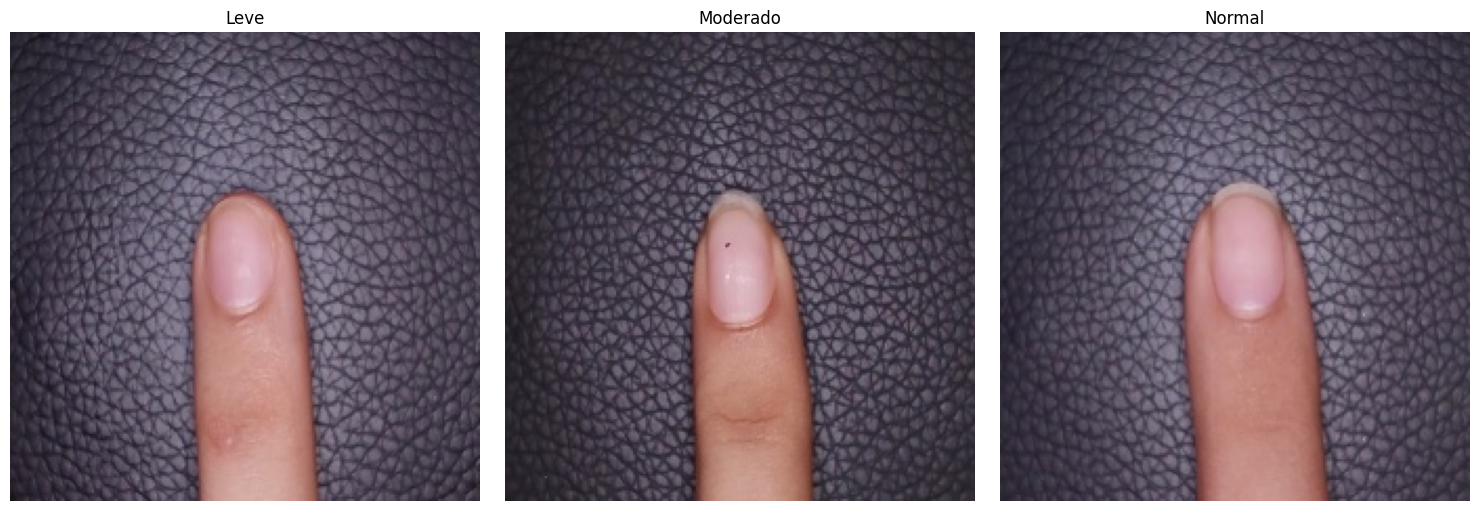

In [12]:
#Step 11 — Random Sample Viewer (Per Class)
classes = sorted(df["class_name"].unique())
fig, axes = plt.subplots(1, len(classes), figsize=(5 * len(classes), 5))

for ax, cls in zip(axes, classes):
    row = df[df["class_name"] == cls].sample(1).iloc[0]
    img = cv2.imread(row["final_path"])
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(cls)
    ax.axis("off")

plt.tight_layout()
plt.show()